In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Loading**

In [ ]:
m0 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/M0/JV.parquet')
p12 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/P12/JV.parquet')

## **Analysis of Voltage Sweep ($V_{span}$) and Validation Criteria**

Applying daytime filter (06:00 - 22:00)...


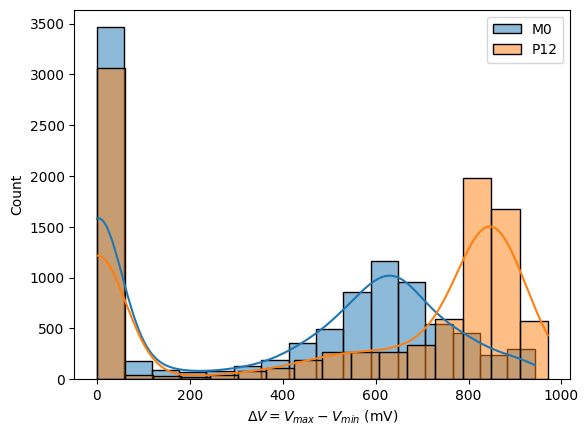

--- Analysis for Cell M0 ---
Total samples: 9572
First bin (0.0 to 58.9 mV):
 -> Count: 3463
 -> Percent: 36.18 %

--- Analysis for Cell P12 ---
Total samples: 9574
First bin (0.0 to 60.7 mV):
 -> Count: 3058
 -> Percent: 31.94 %

Full distribution table for M0 (first 10 rows):
    Start (mV)    End (mV)  Count  Percent (%)
0     0.000000   58.926875   3463    36.178437
1    58.926875  117.853750    182     1.901379
2   117.853750  176.780625     92     0.961137
3   176.780625  235.707500     76     0.793982
4   235.707500  294.634375     77     0.804430
5   294.634375  353.561250    130     1.358128
6   353.561250  412.488125    191     1.995403
7   412.488125  471.415000    361     3.771417
8   471.415000  530.341875    495     5.171333
9   530.341875  589.268750    859     8.974091
10  589.268750  648.195625   1160    12.118679
11  648.195625  707.122500    957     9.997911
12  707.122500  766.049375    546     5.704137
13  766.049375  824.976250    451     4.711659
14  824.976250  

In [ ]:
def analyze_histogram(data, name, n_bins='auto'):
    # 1. Safety drop NaNs
    data = data.dropna()
    total = len(data)

    # 2. Compute histogram (counts and edges)
    counts, bin_edges = np.histogram(data, bins=n_bins)

    # 3. Create DataFrame for visualization
    df_hist = pd.DataFrame({
        'Start (mV)': bin_edges[:-1],
        'End (mV)': bin_edges[1:],
        'Count': counts,
        'Percent (%)': (counts / total) * 100
    })

    # 4. Print stats for the first bin
    print(f"--- Analysis for {name} ---")
    print(f"Total samples: {total}")
    print(f"First bin ({bin_edges[0]:.1f} to {bin_edges[1]:.1f} mV):")
    print(f" -> Count: {counts[0]}")
    print(f" -> Percent: {(counts[0] / total) * 100:.2f} %\n")

    return df_hist

# 1. Processing M0
jv_0 = m0.copy()
jv_0['curve'] = (jv_0['integer4725'] == jv_0['integer4725'].min()).cumsum()
jv_0.loc[np.mod(jv_0['curve'], 2) == 0, 'curve'] -= 1
jv_0.loc[:, 'curve'] = ((jv_0.loc[:, 'curve'] - 1) / 2 + 1).astype('int')

# 2. Processing P12
jv_12 = p12.copy()
jv_12['curve'] = (jv_12['integer4725'] == jv_12['integer4725'].min()).cumsum()
jv_12.loc[np.mod(jv_12['curve'], 2) == 0, 'curve'] -= 1
jv_12.loc[:, 'curve'] = ((jv_12.loc[:, 'curve'] - 1) / 2 + 1).astype('int')

jv_0.insert(0, 'cell_id', 0)
jv_12.insert(0, 'cell_id', 1)

# 3. Concatenation
jv = pd.concat([jv_0, jv_12], axis=0)

# 4. Sweep Direction Identification
jv['int_diff'] = jv['integer4725'].diff().bfill()
jv['is_forward'] = np.where(jv['int_diff'] < 0, 1, 0)

# 5. Global Curve ID Assignment
jv['id_curve'] = jv['curve']
jv.loc[(jv['cell_id'] == 1), 'id_curve'] += jv.loc[(jv['cell_id'] == 0), 'curve'].max()

# 6. Temporal Filtering: Daylight hours (6 AM - 10 PM)
print("Applying daytime filter (06:00 - 22:00)...")
jv['time'] = pd.to_datetime(jv['time'])
jv = jv[jv['time'].dt.time.between(pd.to_datetime('06:00').time(), pd.to_datetime('22:00').time())]

# 7. Voltage Span Calculation (Vmax - Vmin)
volt_diff_0 = jv[jv['cell_id'] == 0].groupby('id_curve')['voltage'].agg(np.ptp)
volt_diff_1 = jv[jv['cell_id'] == 1].groupby('id_curve')['voltage'].agg(np.ptp)

# 8. Plot & Analyze
visual_bins = 16

# Histogram Plot
sns.histplot(volt_diff_0, kde=True, label='M0', bins=visual_bins)
sns.histplot(volt_diff_1, kde=True, label='P12', bins=visual_bins)
plt.xlabel(r'$\Delta V = V_{max} - V_{min} \text{ (mV)}$')
plt.legend()
plt.show()

# Run Analysis
df_m0 = analyze_histogram(volt_diff_0, "Cell M0", n_bins=visual_bins)
df_p12 = analyze_histogram(volt_diff_1, "Cell P12", n_bins=visual_bins)

print("Full distribution table for M0 (first 10 rows):")
print(df_m0)
print("\nFull distribution table for P12 (first 10 rows):")
print(df_p12)

# **Additional Information**

In [ ]:
def add_info(jv, cell_id):
  df = jv[jv['cell_id'] == cell_id].copy()
  df['time'] = pd.to_datetime(df['time'])
  df.set_index('time', inplace=True)
  temp_diff = df[df['integer4725'] == df['integer4725'].min()].index.diff()
  df_duration = []
  df_interval = []
  for k in range(len(temp_diff) // 2):
    j = 2*k+1
    df_duration.append(temp_diff[j])
    n = 2*k
    df_interval.append(temp_diff[n])

  if cell_id == 0:
    cell = 'M0'
  else:
    cell='P12'

  print(f'Average duration of JV curves in {cell}: {np.mean(df_duration)}')
  df_interval.pop(0)
  print(f'Average time between JV curves: {np.mean(np.mean(df_interval))}')
  print(f'No. of curves in {cell}: {df['curve'].max()}')

  curves_day = df['curve'].resample('D').max().diff().fillna(df['curve'].resample('D').max().iloc[0]).astype(int)
  print('\nNumber of curves per day:')
  print(curves_day.head())
  return

In [ ]:
add_info(jv, cell_id=0)
print('\n')
add_info(jv, cell_id=1)

Average duration of JV curves in M0: 0 days 00:04:01.046856770
Average time between JV curves: 0 days 00:03:31.841718075
No. of curves in M0: 14286

Number of curves per day:
time
2025-09-22     41
2025-09-23    285
2025-09-24    285
2025-09-25    285
2025-09-26    285
Freq: D, Name: curve, dtype: int64


Average duration of JV curves in P12: 0 days 00:03:27.648040944
Average time between JV curves: 0 days 00:04:04.957963586
No. of curves in P12: 14302

Number of curves per day:
time
2025-09-22     38
2025-09-23    286
2025-09-24    285
2025-09-25    285
2025-09-26    285
Freq: D, Name: curve, dtype: int64


# **Processing: Curve Identification and Validation**

In [ ]:
def process_jv_curves(m0, p12, v_span_threshold):
    """
    Reads two parquet files, processes JV curves, identifies sweep directions,
    and calculates curve validity based on voltage span.

    Args:
        m0 (pd.DataFrame): Data for cell 0.
        p12 (pd.DataFrame): Data for cell 1.
        v_span_threshold (int): Minimum voltage range for a curve to be valid.

    Returns:
        pd.DataFrame: Combined and processed DataFrame.
    """

    # Helper function to process curve identification (common to both)
    def _process_individual(df_input, cell_id):
        df = df_input.copy()

        # If 'time' is a column, set it as index
        if 'time' in df.columns:
            df.set_index('time', inplace=True)

        # Insert Cell ID
        df.insert(0, 'cell_id', cell_id)

        # Curve identification
        df['curve'] = (df['integer4725'] == df['integer4725'].min()).cumsum()
        df.loc[np.mod(df['curve'], 2) == 0, 'curve'] -= 1
        df['curve'] = ((df['curve'] - 1) / 2 + 1).astype(int)

        return df

    # 1. Individual processing
    jv_0 = _process_individual(m0, 0)
    jv_12 = _process_individual(p12, 1)

    # 2. Concatenation
    jv = pd.concat([jv_0, jv_12], axis=0)

    # 3. current_density
    jv['current_density'] = jv['power'] / jv['voltage'] * 1000  # A/cm2 -> mA/cm2

    # 4. Direction assignment (1: Forward, 0: Reverse)
    jv['int_diff'] = jv['integer4725'].diff()
    jv.loc[jv['int_diff'] == 0, 'int_diff'] = np.nan
    jv['int_diff'] = jv['int_diff'].bfill()
    jv.loc[jv['int_diff'] > 0, 'int_diff'] = 0
    jv.loc[jv['int_diff'] < 0, 'int_diff'] = 1
    jv['int_diff'] = jv['int_diff'].astype(int)
    jv.rename(columns={'int_diff' : 'is_forward'}, inplace=True)

    # 5. Global Curve ID
    jv['id_curve'] = jv['curve']
    max_curve_0 = jv.loc[jv['cell_id'] == 0, 'curve'].max()
    jv.loc[jv['cell_id'] == 1, 'id_curve'] += max_curve_0

    # 6. Voltage Span calculation and Validity (Filter)
    v_span = jv.groupby('id_curve')['voltage'].transform(lambda x: x.max() - x.min())
    jv['v_span'] = v_span
    jv['is_curve_valid'] = (jv['v_span'] > v_span_threshold).astype(int)

    return jv

In [ ]:
v_span_threshold = 200
jv = process_jv_curves(m0, p12, v_span_threshold)

In [ ]:
jv

,cell_id,integer4725,voltage,power,curve,current_density,is_forward,id_curve,v_span,is_curve_valid
time,,,,,,,,,,
2025-09-22 18:36:33.331315,0,1250,720.87,0.187500,1,0.260102,0,1,743.41,1
2025-09-22 18:36:33.512825,0,1255,737.40,0.203125,1,0.275461,0,1,743.41,1
2025-09-22 18:36:33.658098,0,1260,745.80,0.203125,1,0.272359,0,1,743.41,1
2025-09-22 18:36:33.803219,0,1265,751.54,0.218750,1,0.291069,0,1,743.41,1
2025-09-22 18:36:33.948513,0,1270,756.07,0.218750,1,0.289325,0,1,743.41,1
...,...,...,...,...,...,...,...,...,...,...
2025-11-11 22:00:37.598048,1,1270,27.38,0.000000,14303,0.000000,1,28589,0.02,0
2025-11-11 22:00:37.740749,1,1265,27.38,0.000000,14303,0.000000,1,28589,0.02,0
2025-11-11 22:00:37.885717,1,1260,27.38,-0.000000,14303,-0.000000,1,28589,0.02,0


# **Curve Visualization**

In [ ]:
def curve_visualization(jv, id_curve, curve_forward, curve_reverse):

  if curve_forward == True and curve_reverse == True:
    curve_forward = False
    curve_reverse = False

  fig, ax1 = plt.subplots(figsize=(16, 6))

  if curve_forward == True:
    curve = jv.loc[(jv['id_curve'] == id_curve) & (jv['is_forward'] == 1), :]
  elif curve_reverse == True:
    curve = jv.loc[(jv['id_curve'] == id_curve) & (jv['is_forward'] == 0), :]
  else:
    curve = jv[jv['id_curve'] == id_curve]

  # Extract cell_id and date from the current curve
  current_cell_id = curve['cell_id'].iloc[0]
  current_date = curve.index[0].date()

  ax1.plot(curve['voltage'], curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
  ax1.set_xlabel('Voltage (mV)', fontsize=16)
  ax1.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=16)
  ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
  ax1.tick_params(axis='x', labelsize=14)
  plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

  ax2 = ax1.twinx()

  ax2.plot(curve['voltage'], curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
  ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=16)
  ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)
  plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

  ax1.legend(loc='upper left')
  ax2.legend(loc='upper right')

  # Use the extracted current_date and current_cell_id for the title
  plt.title(f'Power and Current Density Curves for {current_date} (Curve ID: {id_curve}) (Cell ID: {current_cell_id})', fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

  print(curve[['integer4725', 'voltage', 'power', 'current_density']])

  return

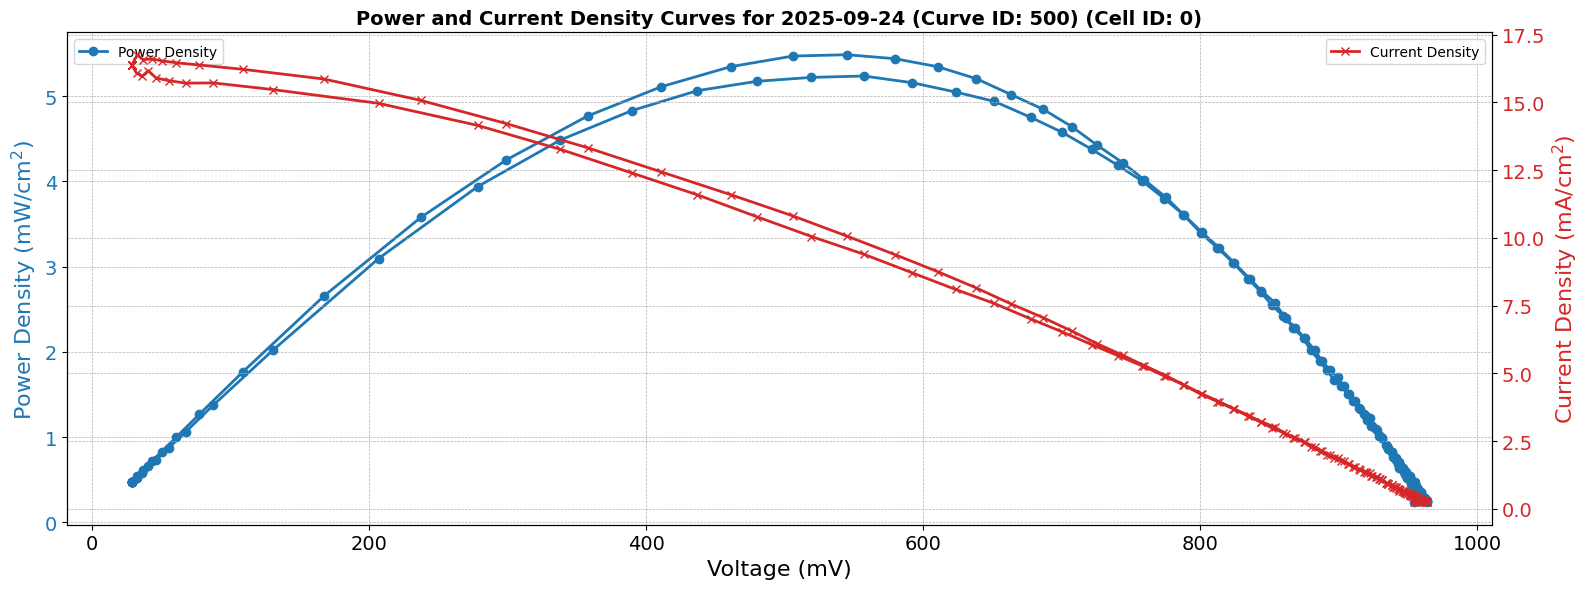

                            integer4725  voltage     power  current_density
time                                                                       
2025-09-24 12:40:28.691106         1250   954.07  0.234375         0.245658
2025-09-24 12:40:28.835118         1255   955.53  0.250000         0.261635
2025-09-24 12:40:28.980640         1260   957.13  0.250000         0.261198
2025-09-24 12:40:29.125757         1265   957.53  0.250000         0.261088
2025-09-24 12:40:29.271079         1270   958.20  0.281250         0.293519
...                                 ...      ...       ...              ...
2025-09-24 12:40:52.646210         1270   963.13  0.265625         0.275794
2025-09-24 12:40:52.791549         1265   963.27  0.265625         0.275753
2025-09-24 12:40:52.936827         1260   963.40  0.250000         0.259498
2025-09-24 12:40:53.082190         1255   963.40  0.250000         0.259498
2025-09-24 12:40:53.227400         1250   963.93  0.234375         0.243145

[170 rows x

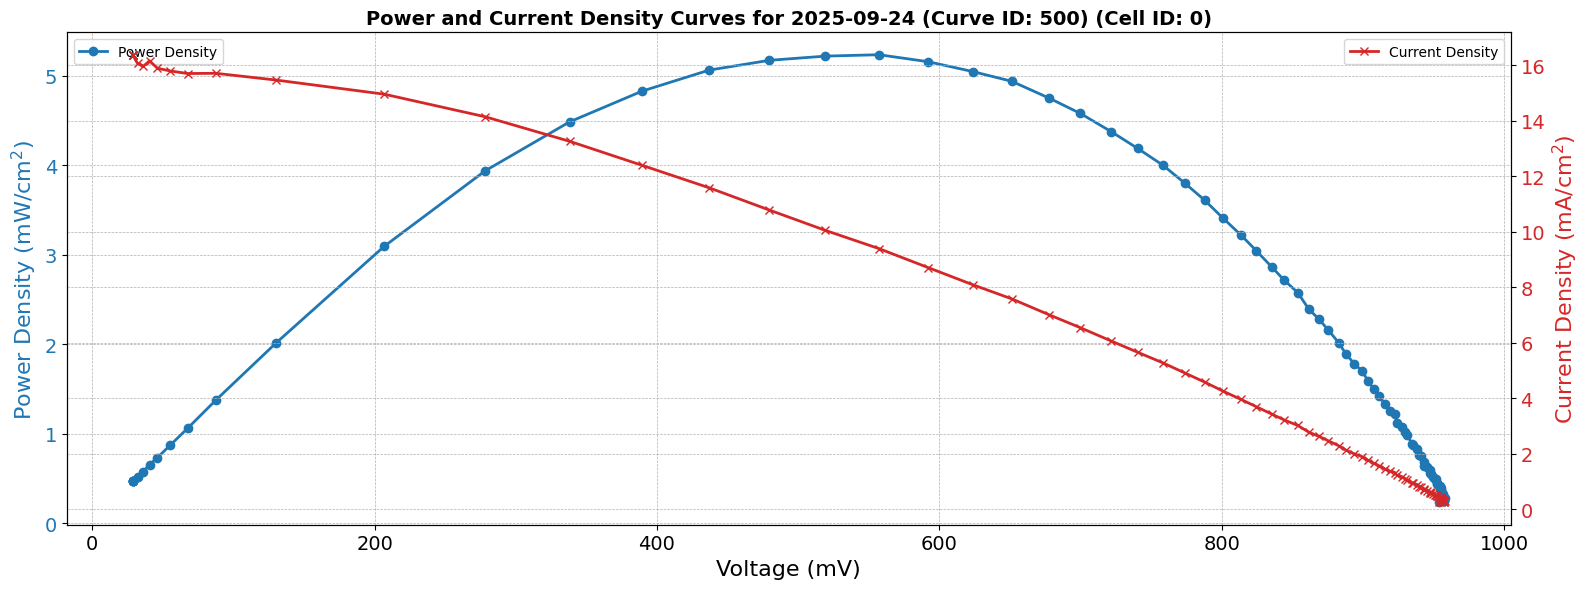

                            integer4725  voltage     power  current_density
time                                                                       
2025-09-24 12:40:28.691106         1250   954.07  0.234375         0.245658
2025-09-24 12:40:28.835118         1255   955.53  0.250000         0.261635
2025-09-24 12:40:28.980640         1260   957.13  0.250000         0.261198
2025-09-24 12:40:29.125757         1265   957.53  0.250000         0.261088
2025-09-24 12:40:29.271079         1270   958.20  0.281250         0.293519
...                                 ...      ...       ...              ...
2025-09-24 12:40:40.307519         1650    28.61  0.468750        16.384131
2025-09-24 12:40:40.452474         1655    28.62  0.468750        16.378407
2025-09-24 12:40:40.597290         1660    28.62  0.468750        16.378407
2025-09-24 12:40:40.742127         1665    28.62  0.468750        16.378407
2025-09-24 12:40:40.886926         1670    28.63  0.468750        16.372686

[85 rows x 

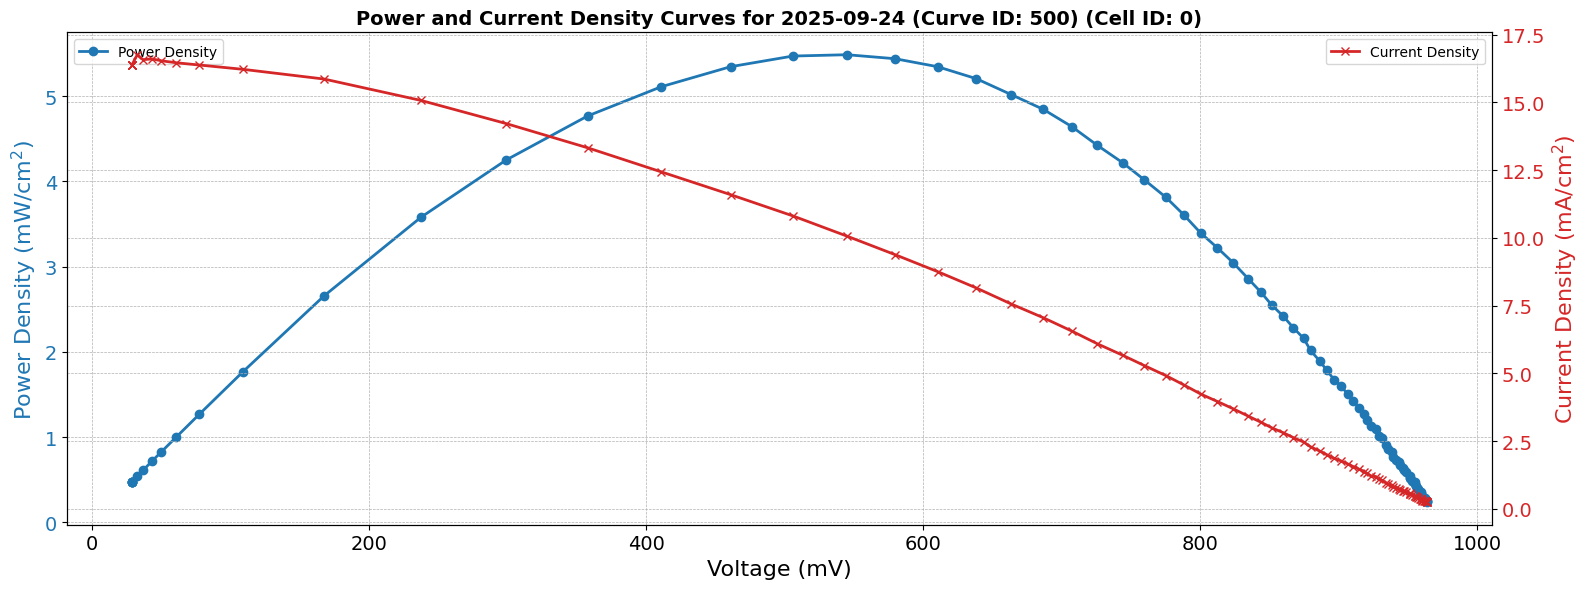

                            integer4725  voltage     power  current_density
time                                                                       
2025-09-24 12:40:41.031723         1670    28.63  0.468750        16.372686
2025-09-24 12:40:41.176451         1665    28.63  0.468750        16.372686
2025-09-24 12:40:41.321157         1660    28.63  0.468750        16.372686
2025-09-24 12:40:41.465923         1655    28.63  0.468750        16.372686
2025-09-24 12:40:41.610608         1650    28.64  0.468750        16.366969
...                                 ...      ...       ...              ...
2025-09-24 12:40:52.646210         1270   963.13  0.265625         0.275794
2025-09-24 12:40:52.791549         1265   963.27  0.265625         0.275753
2025-09-24 12:40:52.936827         1260   963.40  0.250000         0.259498
2025-09-24 12:40:53.082190         1255   963.40  0.250000         0.259498
2025-09-24 12:40:53.227400         1250   963.93  0.234375         0.243145

[85 rows x 

In [ ]:
id_curve = 500
curve_visualization(jv, id_curve, curve_forward = True, curve_reverse = True)
print('\n')
curve_visualization(jv, id_curve, curve_forward = False, curve_reverse = True)
print('\n')
curve_visualization(jv, id_curve, curve_forward = True, curve_reverse = False)

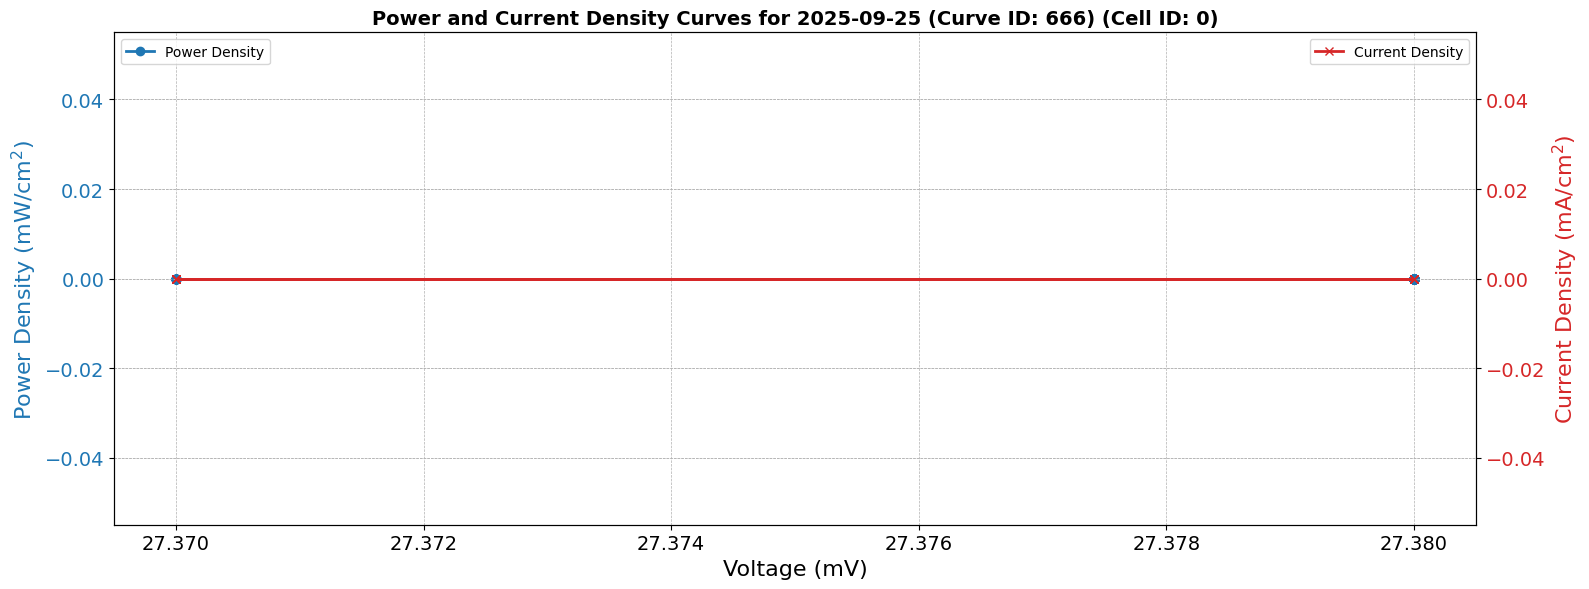

                            integer4725  voltage  power  current_density
time                                                                    
2025-09-25 02:38:42.273681         1250    27.38   -0.0             -0.0
2025-09-25 02:38:42.412607         1255    27.37   -0.0             -0.0
2025-09-25 02:38:42.556895         1260    27.38   -0.0             -0.0
2025-09-25 02:38:42.701093         1265    27.38   -0.0             -0.0
2025-09-25 02:38:42.844748         1270    27.37   -0.0             -0.0
...                                 ...      ...    ...              ...
2025-09-25 02:39:06.037093         1270    27.37   -0.0             -0.0
2025-09-25 02:39:06.181079         1265    27.37   -0.0             -0.0
2025-09-25 02:39:06.325331         1260    27.38   -0.0             -0.0
2025-09-25 02:39:06.469396         1255    27.38   -0.0             -0.0
2025-09-25 02:39:06.613494         1250    27.38   -0.0             -0.0

[170 rows x 4 columns]




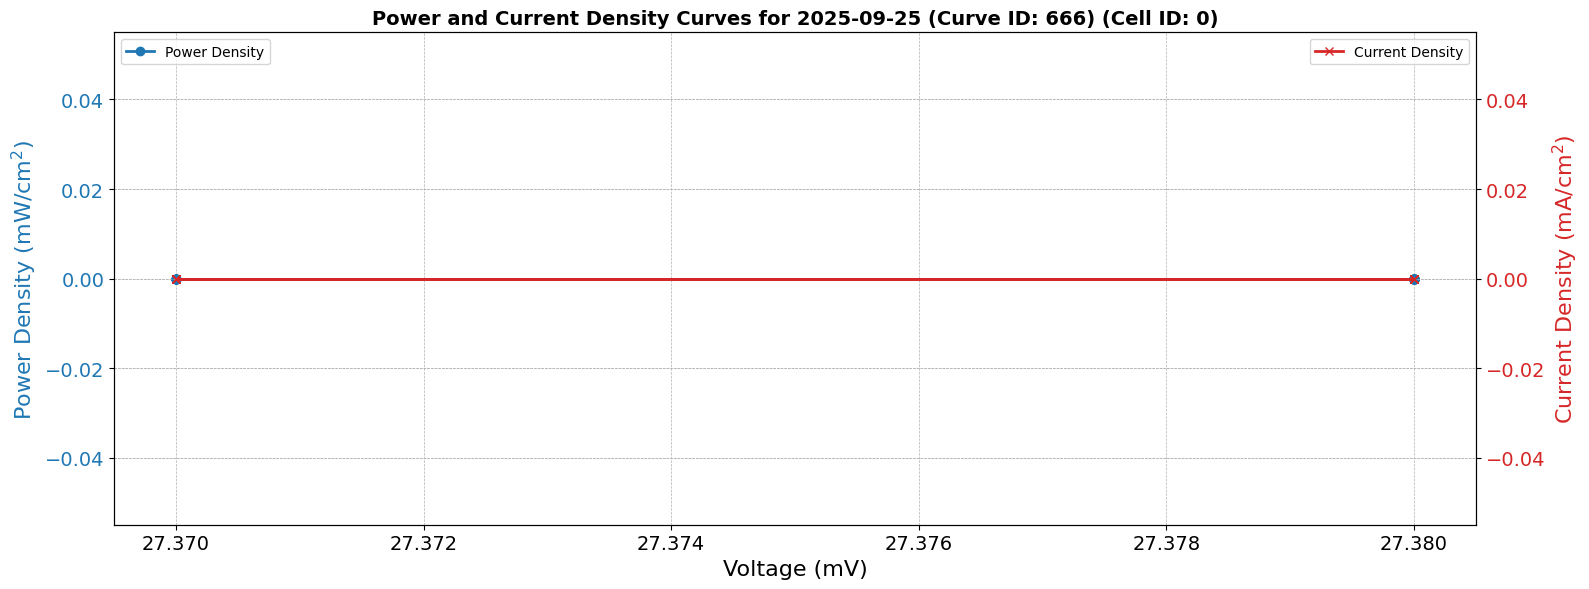

                            integer4725  voltage  power  current_density
time                                                                    
2025-09-25 02:38:42.273681         1250    27.38   -0.0             -0.0
2025-09-25 02:38:42.412607         1255    27.37   -0.0             -0.0
2025-09-25 02:38:42.556895         1260    27.38   -0.0             -0.0
2025-09-25 02:38:42.701093         1265    27.38   -0.0             -0.0
2025-09-25 02:38:42.844748         1270    27.37   -0.0             -0.0
...                                 ...      ...    ...              ...
2025-09-25 02:38:53.793110         1650    27.38   -0.0             -0.0
2025-09-25 02:38:53.937096         1655    27.37   -0.0             -0.0
2025-09-25 02:38:54.081294         1660    27.38   -0.0             -0.0
2025-09-25 02:38:54.225230         1665    27.38   -0.0             -0.0
2025-09-25 02:38:54.368963         1670    27.38   -0.0             -0.0

[85 rows x 4 columns]




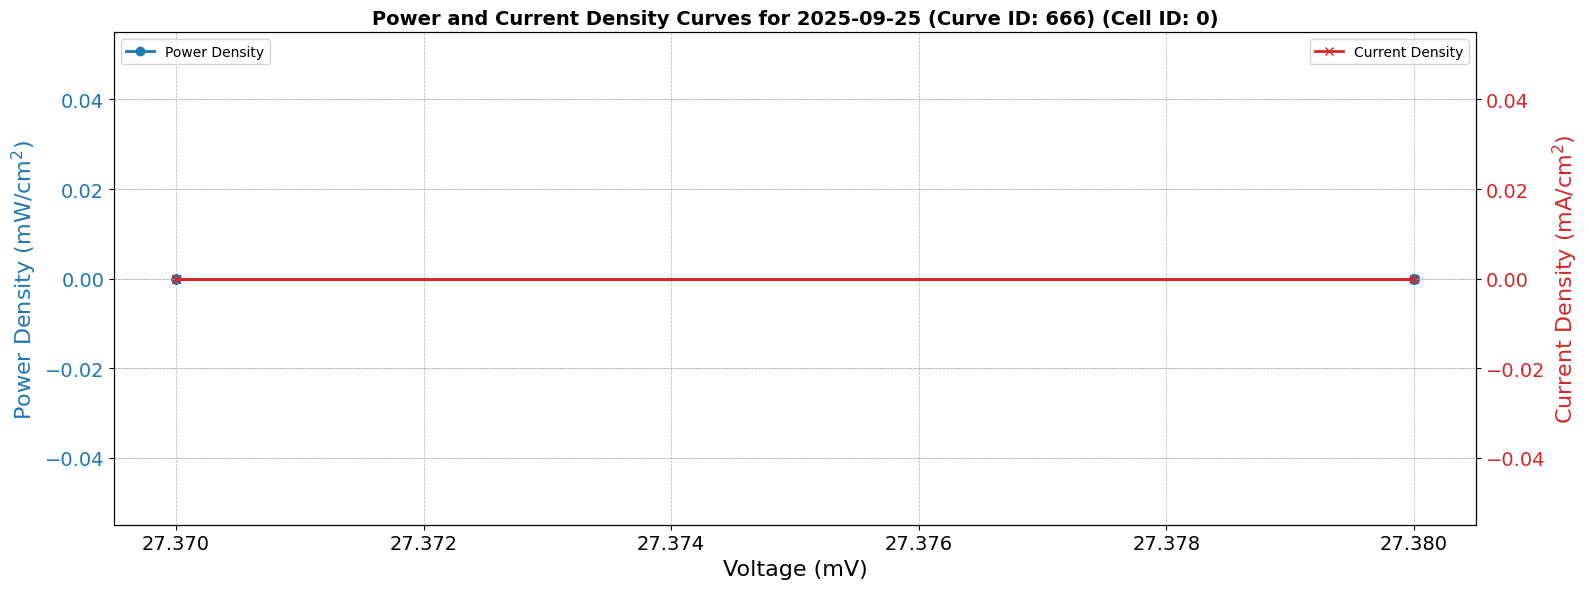

                            integer4725  voltage  power  current_density
time                                                                    
2025-09-25 02:38:54.513128         1670    27.38   -0.0             -0.0
2025-09-25 02:38:54.657057         1665    27.37   -0.0             -0.0
2025-09-25 02:38:54.801119         1660    27.38   -0.0             -0.0
2025-09-25 02:38:54.945001         1655    27.38   -0.0             -0.0
2025-09-25 02:38:55.089068         1650    27.38   -0.0             -0.0
...                                 ...      ...    ...              ...
2025-09-25 02:39:06.037093         1270    27.37   -0.0             -0.0
2025-09-25 02:39:06.181079         1265    27.37   -0.0             -0.0
2025-09-25 02:39:06.325331         1260    27.38   -0.0             -0.0
2025-09-25 02:39:06.469396         1255    27.38   -0.0             -0.0
2025-09-25 02:39:06.613494         1250    27.38   -0.0             -0.0

[85 rows x 4 columns]


In [ ]:
id_curve = 666
curve_visualization(jv, id_curve, curve_forward = True, curve_reverse = True)
print('\n')
curve_visualization(jv, id_curve, curve_forward = False, curve_reverse = True)
print('\n')
curve_visualization(jv, id_curve, curve_forward = True, curve_reverse = False)

# **Top 4 JV Curves (Maximum Power Point)**

In [ ]:
def jv_cell_visualization(jv, cell_id):
  jv = jv.loc[jv['cell_id'] == cell_id, :]
  jv.index = jv.index.date
  jv.index.name='time'
  days = np.unique(jv.index)
  best_days = jv.groupby(jv.index).apply(lambda x: x.loc[x['power'] == x['power'].max()].max()).sort_values('power', ascending=False)

  return jv, days, best_days

In [ ]:
def plot_four_best_curves(cell_id):
    # 1. Data retrieval
    df, days, best_days = jv_cell_visualization(jv, cell_id)

    # 2. 2x2 Matrix Figure Configuration
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    axs = axs.flatten()

    k_values = [0, 1, 2, 3]

    for k, ax in zip(k_values, axs):
        # Selection of the day based on best_days ranking
        current_day_label = best_days.index[k]
        best_day_k = df.loc[current_day_label]

        # Curve identification and initial selection of the best one
        best_day_k_curves = best_day_k.groupby('curve')['power'].max()
        best_day_k_curves = best_day_k_curves.sort_values(ascending=False)

        # Initial attempt with the maximum power curve
        best_day_k_best_curve = best_day_k.loc[best_day_k['curve'] == best_day_k_curves.idxmax()]

        # ------------------------------------------------------------------------------------------------
        # FILTER: If the curve is invalid, iterate over the next best ones
        # ------------------------------------------------------------------------------------------------
        if best_day_k_best_curve.is_curve_valid.sum() == 0:
            for c in range(1, len(best_day_k_curves.index)):
                candidate_curve = best_day_k.loc[best_day_k['curve'] == best_day_k_curves.index[c]]
                if candidate_curve.is_curve_valid.sum() != 0:
                    best_day_k_best_curve = candidate_curve
                    break

        # ------------------------------------------------------------------------------------------------
        # PARAMETER CALCULATIONS (DPM, Vmpp, Jmpp, Voc, Jsc, FF)
        # ------------------------------------------------------------------------------------------------
        DPM = best_day_k_best_curve.power.max()

        # Find the MPP point to obtain Vmpp and Jmpp
        mpp_data = best_day_k_best_curve.loc[best_day_k_best_curve['power'] == DPM].iloc[0]
        Vmpp = mpp_data['voltage']
        Jmpp = mpp_data['current_density']

        Voc = best_day_k_best_curve.voltage.max()
        Jsc = best_day_k_best_curve['current_density'].max()
        FF = (Vmpp * Jmpp) / (Voc * Jsc) if (Voc * Jsc) != 0 else 0

        # ------------------------------------------------------------------------------------------------
        # PLOTTING ON THE MATRIX
        # ------------------------------------------------------------------------------------------------
        # Primary Axis (Power)
        ax.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
        ax.set_xlabel('Voltage (mV)', fontsize=12)
        ax.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=12)
        ax.tick_params(axis='y', labelcolor='tab:blue', labelsize=10)
        ax.tick_params(axis='x', labelsize=10)
        ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

        # Secondary Axis (Current)
        ax2 = ax.twinx()
        ax2.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
        ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=12)
        ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=10)

        # Subplot Title
        # Use current_day_label to ensure the displayed date matches the ranking
        ax.set_title(f'# {k+1}: {current_day_label} - Pmax={DPM:.3f} mW/cm² - FF={FF:.3f}', fontsize=13, fontweight='bold')

        if cell_id == 0:
          cell = 'M0'
        else:
            cell='P12'

        fig.suptitle(f"Top 4 Curves (Highest Maximum Power) for {cell}", fontsize=20, fontweight='bold')

    # Final adjustment of the matrix
    plt.tight_layout()
    plt.show()
    return

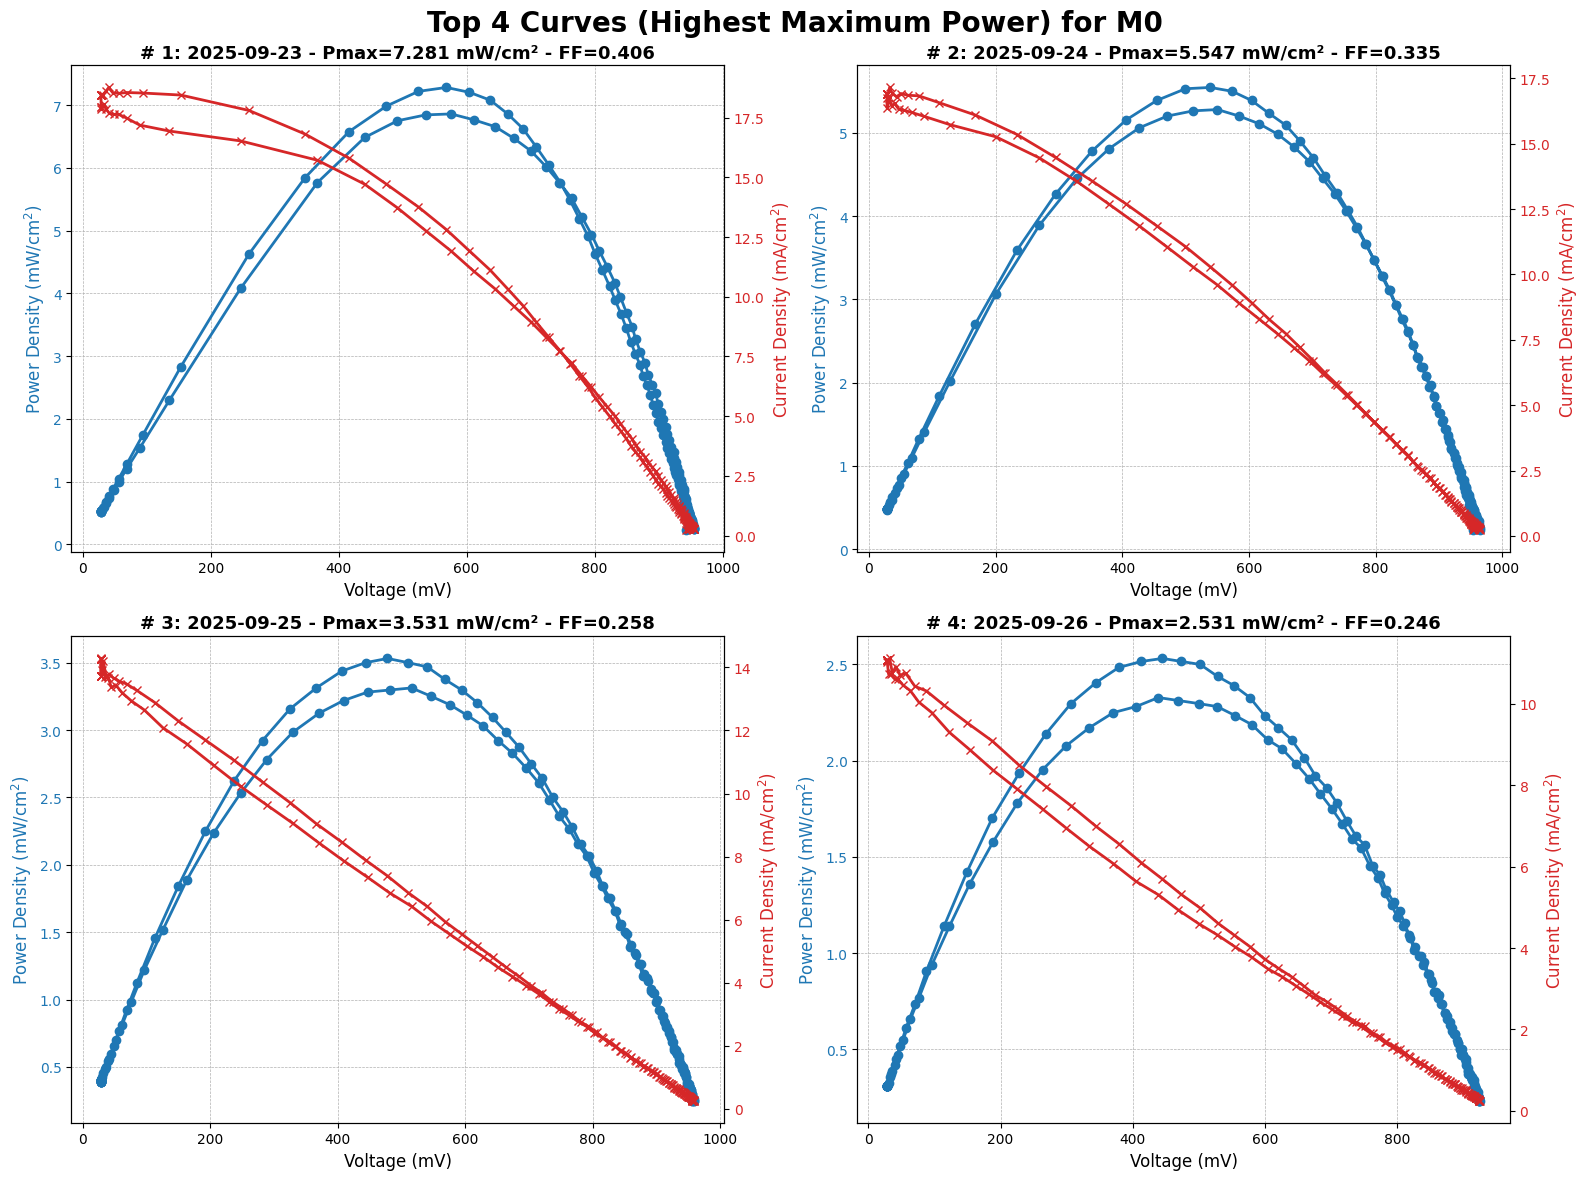

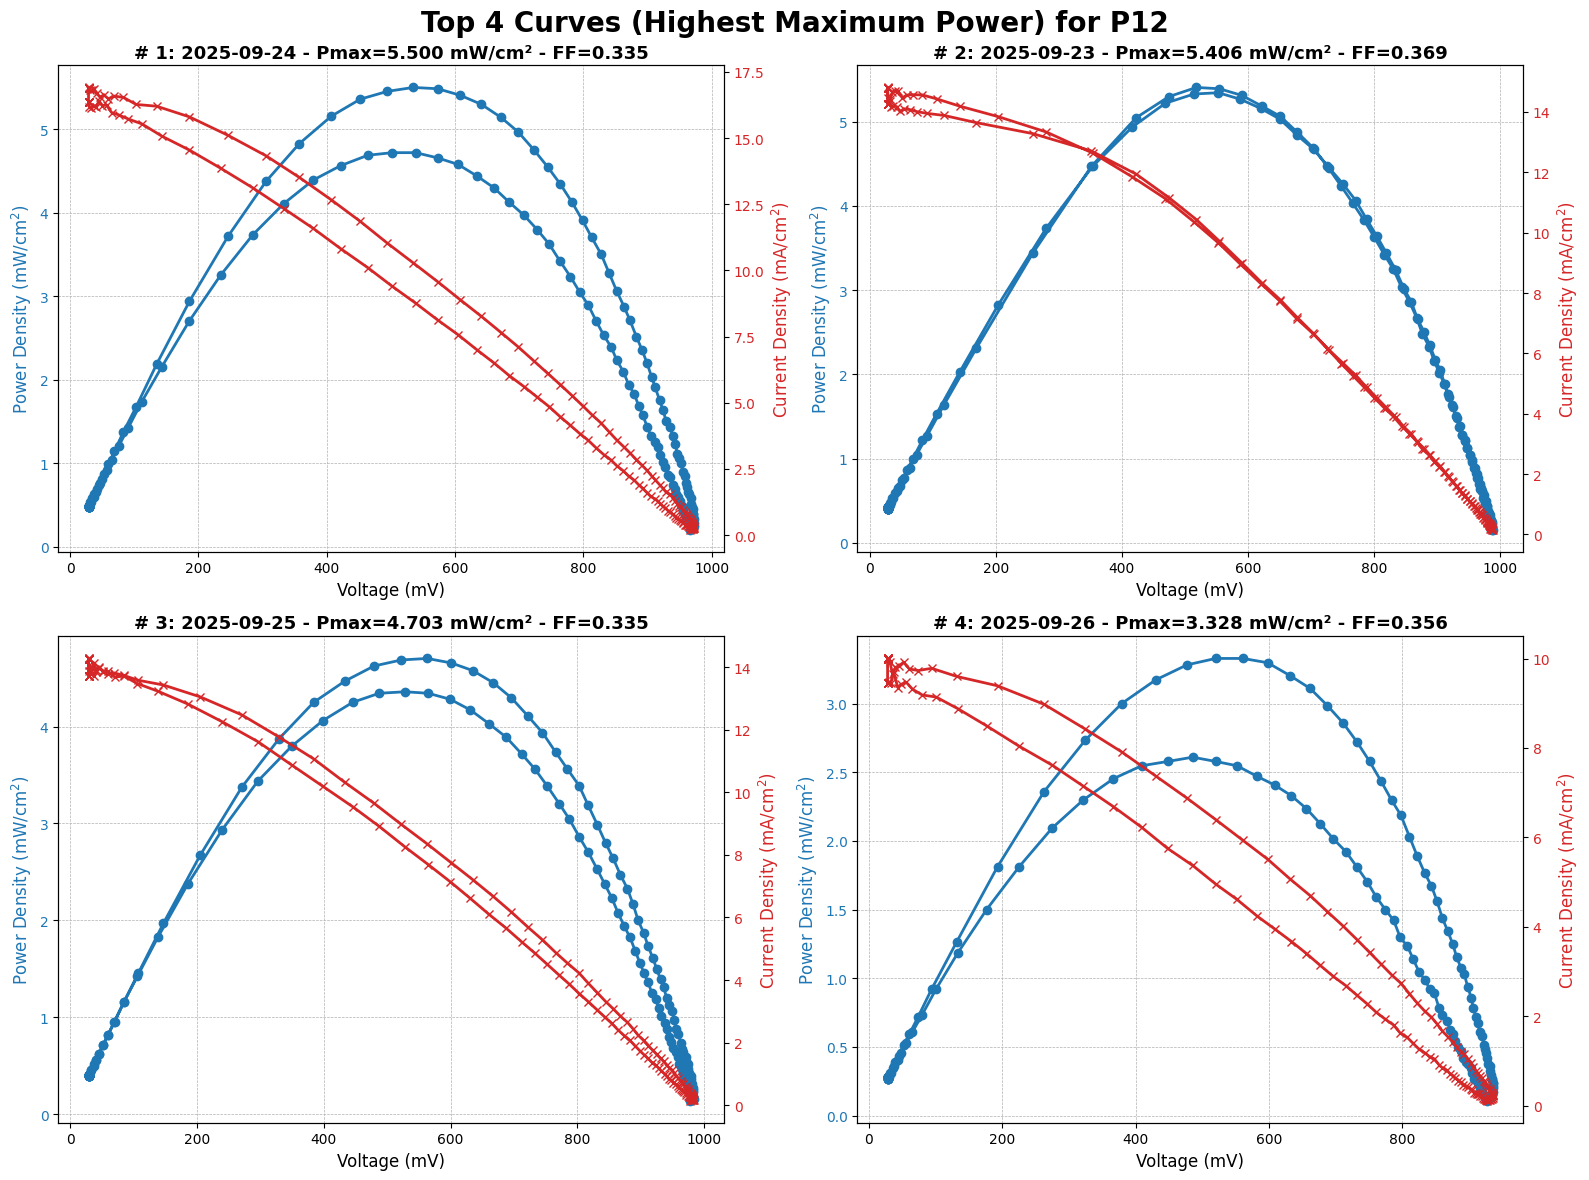

In [ ]:
# cell_id = 1
for cell_id in range(0,2):
  plot_four_best_curves(cell_id)
  print('\n')

# **JV Photovoltaic Parameter Extraction: Daily Pmax, Vmpp, Jmpp, Voc, & Jsc**

$$ FF = \frac{V_{mpp} \cdot J_{mpp}}{V_{oc} \cdot J_{sc}}, \quad FF_v = \frac{V_{mpp}}{V_{oc}}, \quad FF_j = \frac{J_{mpp}}{J_{sc}} $$


In [ ]:
def plot_curves(jv, cell_id, filter, plot_pow_den_curves, plot_parameters):
    df, days, best_days = jv_cell_visualization(jv, cell_id)

    if df['cell_id'].unique() == 0:
        cell_id = 'M0'
    else:
        cell_id = 'P12'

    k_values = list(range(0, len(days)))
    id_curve = []
    DPM = []
    Vmpp = []
    Jmpp = []
    Voc = []
    Jsc = []
    d = []

    for k in k_values:
        best_day_k = df.loc[df.index == days[k], :]
        best_day_k_curves = best_day_k.groupby('curve')['power'].max()
        best_day_k_curves.sort_values(ascending=False, inplace=True)
        best_day_k_best_curve = best_day_k.groupby('time').apply(lambda x: x.loc[x['curve'] == best_day_k_curves.index[0]])

        # ------------------------------------------------------------------------------------------------
        # FILTER
        # ------------------------------------------------------------------------------------------------
        if filter == True and best_day_k_best_curve.is_curve_valid.sum() == 0:
            for c in range(1, len(best_day_k_curves.index)):
                best_day_k_best_curve = best_day_k.groupby('time').apply(lambda x: x.loc[x['curve'] == best_day_k_curves.index[c]])

                if best_day_k_best_curve.power.sum() != 0:
                    d.append(k)
                    id_curve.append(best_day_k_best_curve.id_curve.iloc[0].item())
                    DPM.append(best_day_k_best_curve.power.max())
                    Vmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['voltage'].iloc[0].item())
                    Jmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['current_density'].iloc[0].item())
                    Voc.append(best_day_k_best_curve.voltage.max())
                    Jsc.append(best_day_k_best_curve['current_density'].max())

                    if plot_pow_den_curves == True:
                        fig, ax1 = plt.subplots(figsize=(16, 6))
                        ax1.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
                        ax1.set_xlabel('Voltage (mV)', fontsize=16)
                        ax1.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=16)
                        ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
                        ax1.tick_params(axis='x', labelsize=14)
                        plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                        ax2 = ax1.twinx()
                        ax2.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
                        ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=16)
                        ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)
                        plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                        ax1.legend(loc='upper left')
                        ax2.legend(loc='upper right')
                        plt.title(f'Power and Current Density Curves for the day {days[k]} ({k+1}) ({cell_id}) (Filtered)', fontsize=14, fontweight='bold')
                        plt.tight_layout()
                        plt.show()
                    break
        else:
            # -------------------------------------------------------------------------------------------------
            d.append(k)
            id_curve.append(best_day_k_best_curve.id_curve.iloc[0].item())
            DPM.append(best_day_k_best_curve.power.max())
            Vmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['voltage'].iloc[0].item())
            Jmpp.append(best_day_k_best_curve.groupby('time').apply(lambda x: x.loc[x['power'] == x['power'].max()])['current_density'].iloc[0].item())
            Voc.append(best_day_k_best_curve.voltage.max())
            Jsc.append(best_day_k_best_curve['current_density'].max())

            if plot_pow_den_curves == True:
                fig, ax1 = plt.subplots(figsize=(16, 6))
                ax1.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['power'], label='Power Density', color='tab:blue', marker='o', linewidth=2)
                ax1.set_xlabel('Voltage (mV)', fontsize=16)
                ax1.set_ylabel('Power Density (mW/cm$^{2}$)', color='tab:blue', fontsize=16)
                ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
                ax1.tick_params(axis='x', labelsize=14)
                plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                ax2 = ax1.twinx()
                ax2.plot(best_day_k_best_curve['voltage'], best_day_k_best_curve['current_density'], label='Current Density', color='tab:red', marker='x', linewidth=2)
                ax2.set_ylabel('Current Density (mA/cm$^2$)', color='tab:red', fontsize=16)
                ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)
                plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)

                ax1.legend(loc='upper left')
                ax2.legend(loc='upper right')
                plt.title(f'Power and Current Density Curves for the day {days[k]} ({k+1}) ({cell_id})', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.show()

    df_all = pd.DataFrame({
        'time': [days[i] for i in d],
        'id_curve': id_curve,
        'DPM': DPM,
        'Vmpp': Vmpp,
        'Jmpp': Jmpp,
        'Voc': Voc,
        'Jsc': Jsc,
        'FF': (np.array(Vmpp) * np.array(Jmpp)) / (np.array(Voc) * np.array(Jsc)),
        'FFv': np.array(Vmpp) / np.array(Voc),
        'FFj': np.array(Jmpp) / np.array(Jsc)
    })
    df_all.set_index('time', inplace=True)

    if plot_parameters == True:
        title_font = {'weight': 'bold', 'size': 16}
        label_font = {'weight': 'normal', 'size': 14}
        tick_size = 12

        fig, axs = plt.subplots(4, 1, figsize=(16, 24))

        axs[0].plot(df_all.index, df_all['DPM'], marker='o')
        axs[0].grid(True)
        axs[0].set_ylabel('Power (mW/cm$^2$)', fontdict=label_font)
        axs[0].set_title(f'Daily Power Max ({cell_id})', fontdict=title_font)
        axs[0].tick_params(axis='both', which='major', labelsize=tick_size)

        axs[1].plot(df_all.index, df_all['Voc'], marker='o', color='cyan', label='Voc')
        axs[1].plot(df_all.index, df_all['Vmpp'], marker='o', color='blue', label='Vmpp')
        axs[1].grid(True)
        axs[1].set_ylabel('Voltage (mV/cm$^2$)', fontdict=label_font)
        axs[1].set_title(f'Voc & Vmpp ({cell_id})', fontdict=title_font)
        axs[1].legend(loc='upper right', fontsize=12)
        axs[1].tick_params(axis='both', which='major', labelsize=tick_size)

        axs[2].plot(df_all.index, df_all['Jsc'], marker='o', color='mediumseagreen', label='Jsc')
        axs[2].plot(df_all.index, df_all['Jmpp'], marker='o', color='darkgreen', label='Jmpp')
        axs[2].grid(True)
        axs[2].set_ylabel('Current Density (mA/cm$^2$)', fontdict=label_font)
        axs[2].set_title(f'Jsc & Jmpp ({cell_id})', fontdict=title_font)
        axs[2].legend(loc='upper right', fontsize=12)
        axs[2].tick_params(axis='both', which='major', labelsize=tick_size)

        axs[3].plot(df_all.index, df_all['FF'], label='FF', marker='o', color='purple')
        axs[3].plot(df_all.index, df_all['FFv'], label='FFv', marker='s', color='magenta')
        axs[3].plot(df_all.index, df_all['FFj'], label='FFj', marker='^', color='orange')
        axs[3].grid(True)
        axs[3].set_ylabel('FF', fontdict=label_font)
        axs[3].set_title(f'FF, FFv, and FFj ({cell_id})', fontdict=title_font)
        axs[3].legend(fontsize=12)
        axs[3].tick_params(axis='both', which='major', labelsize=tick_size)

        plt.tight_layout()
        plt.show()

    return df_all

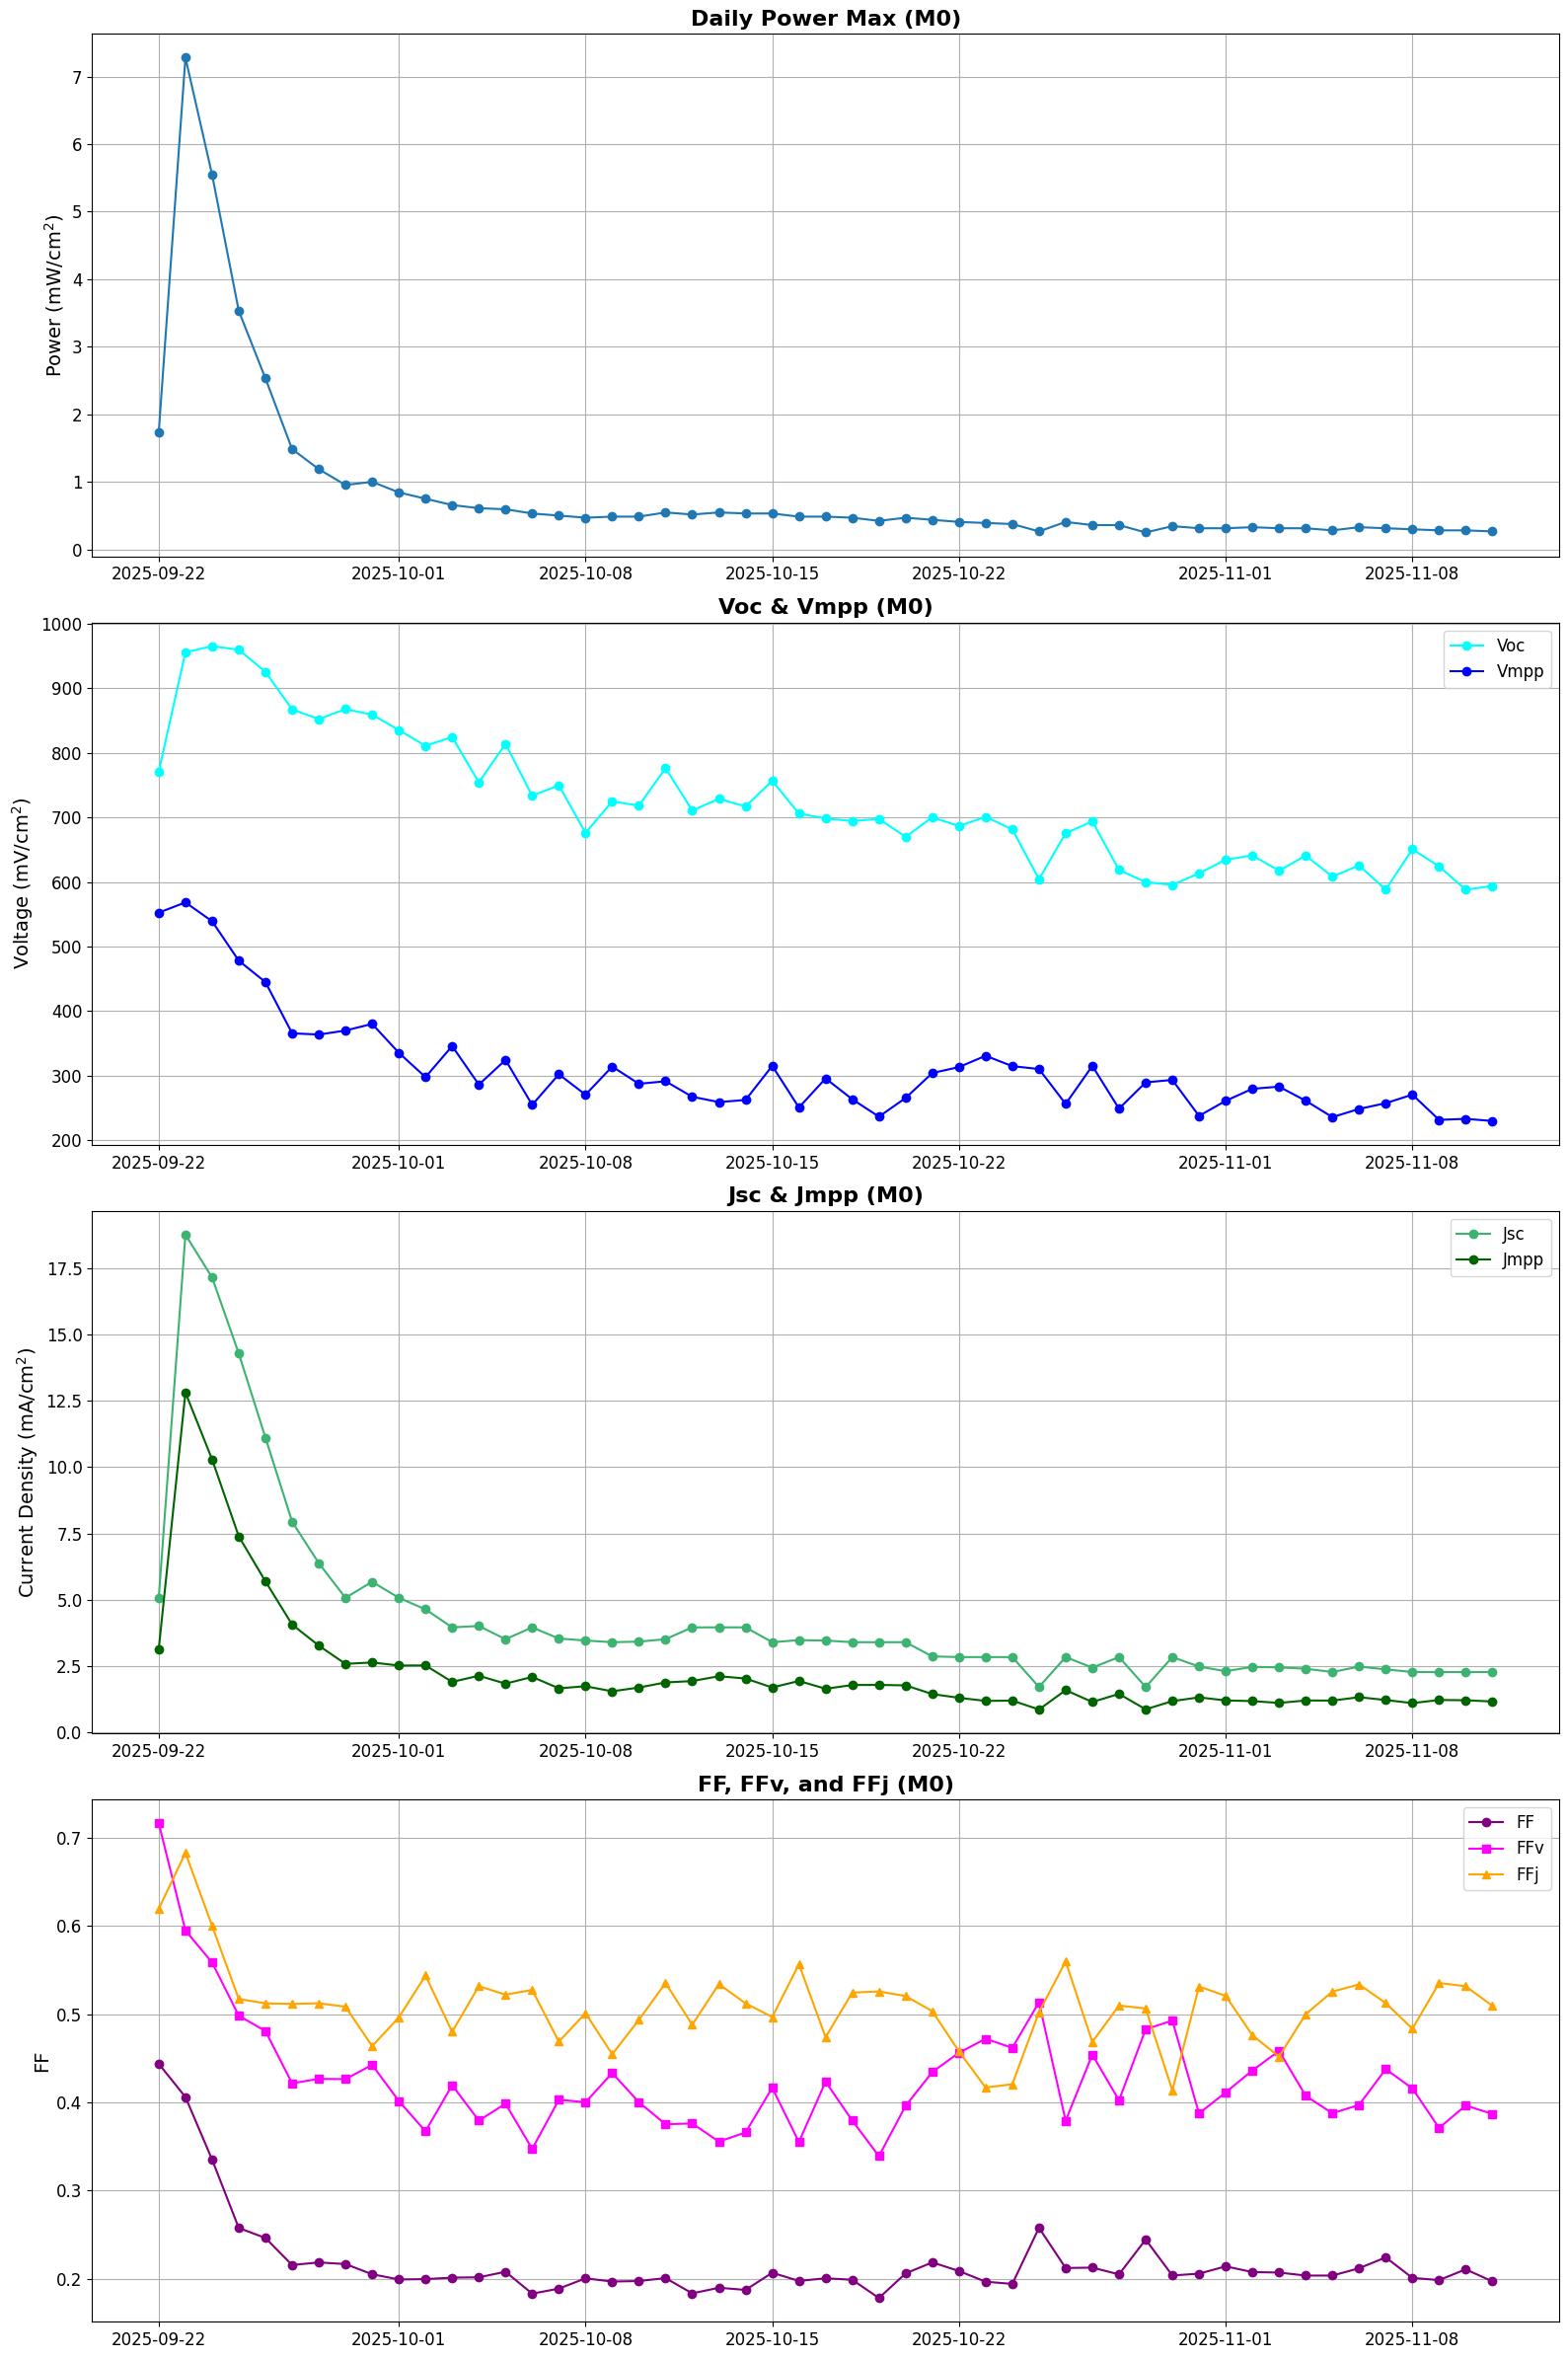

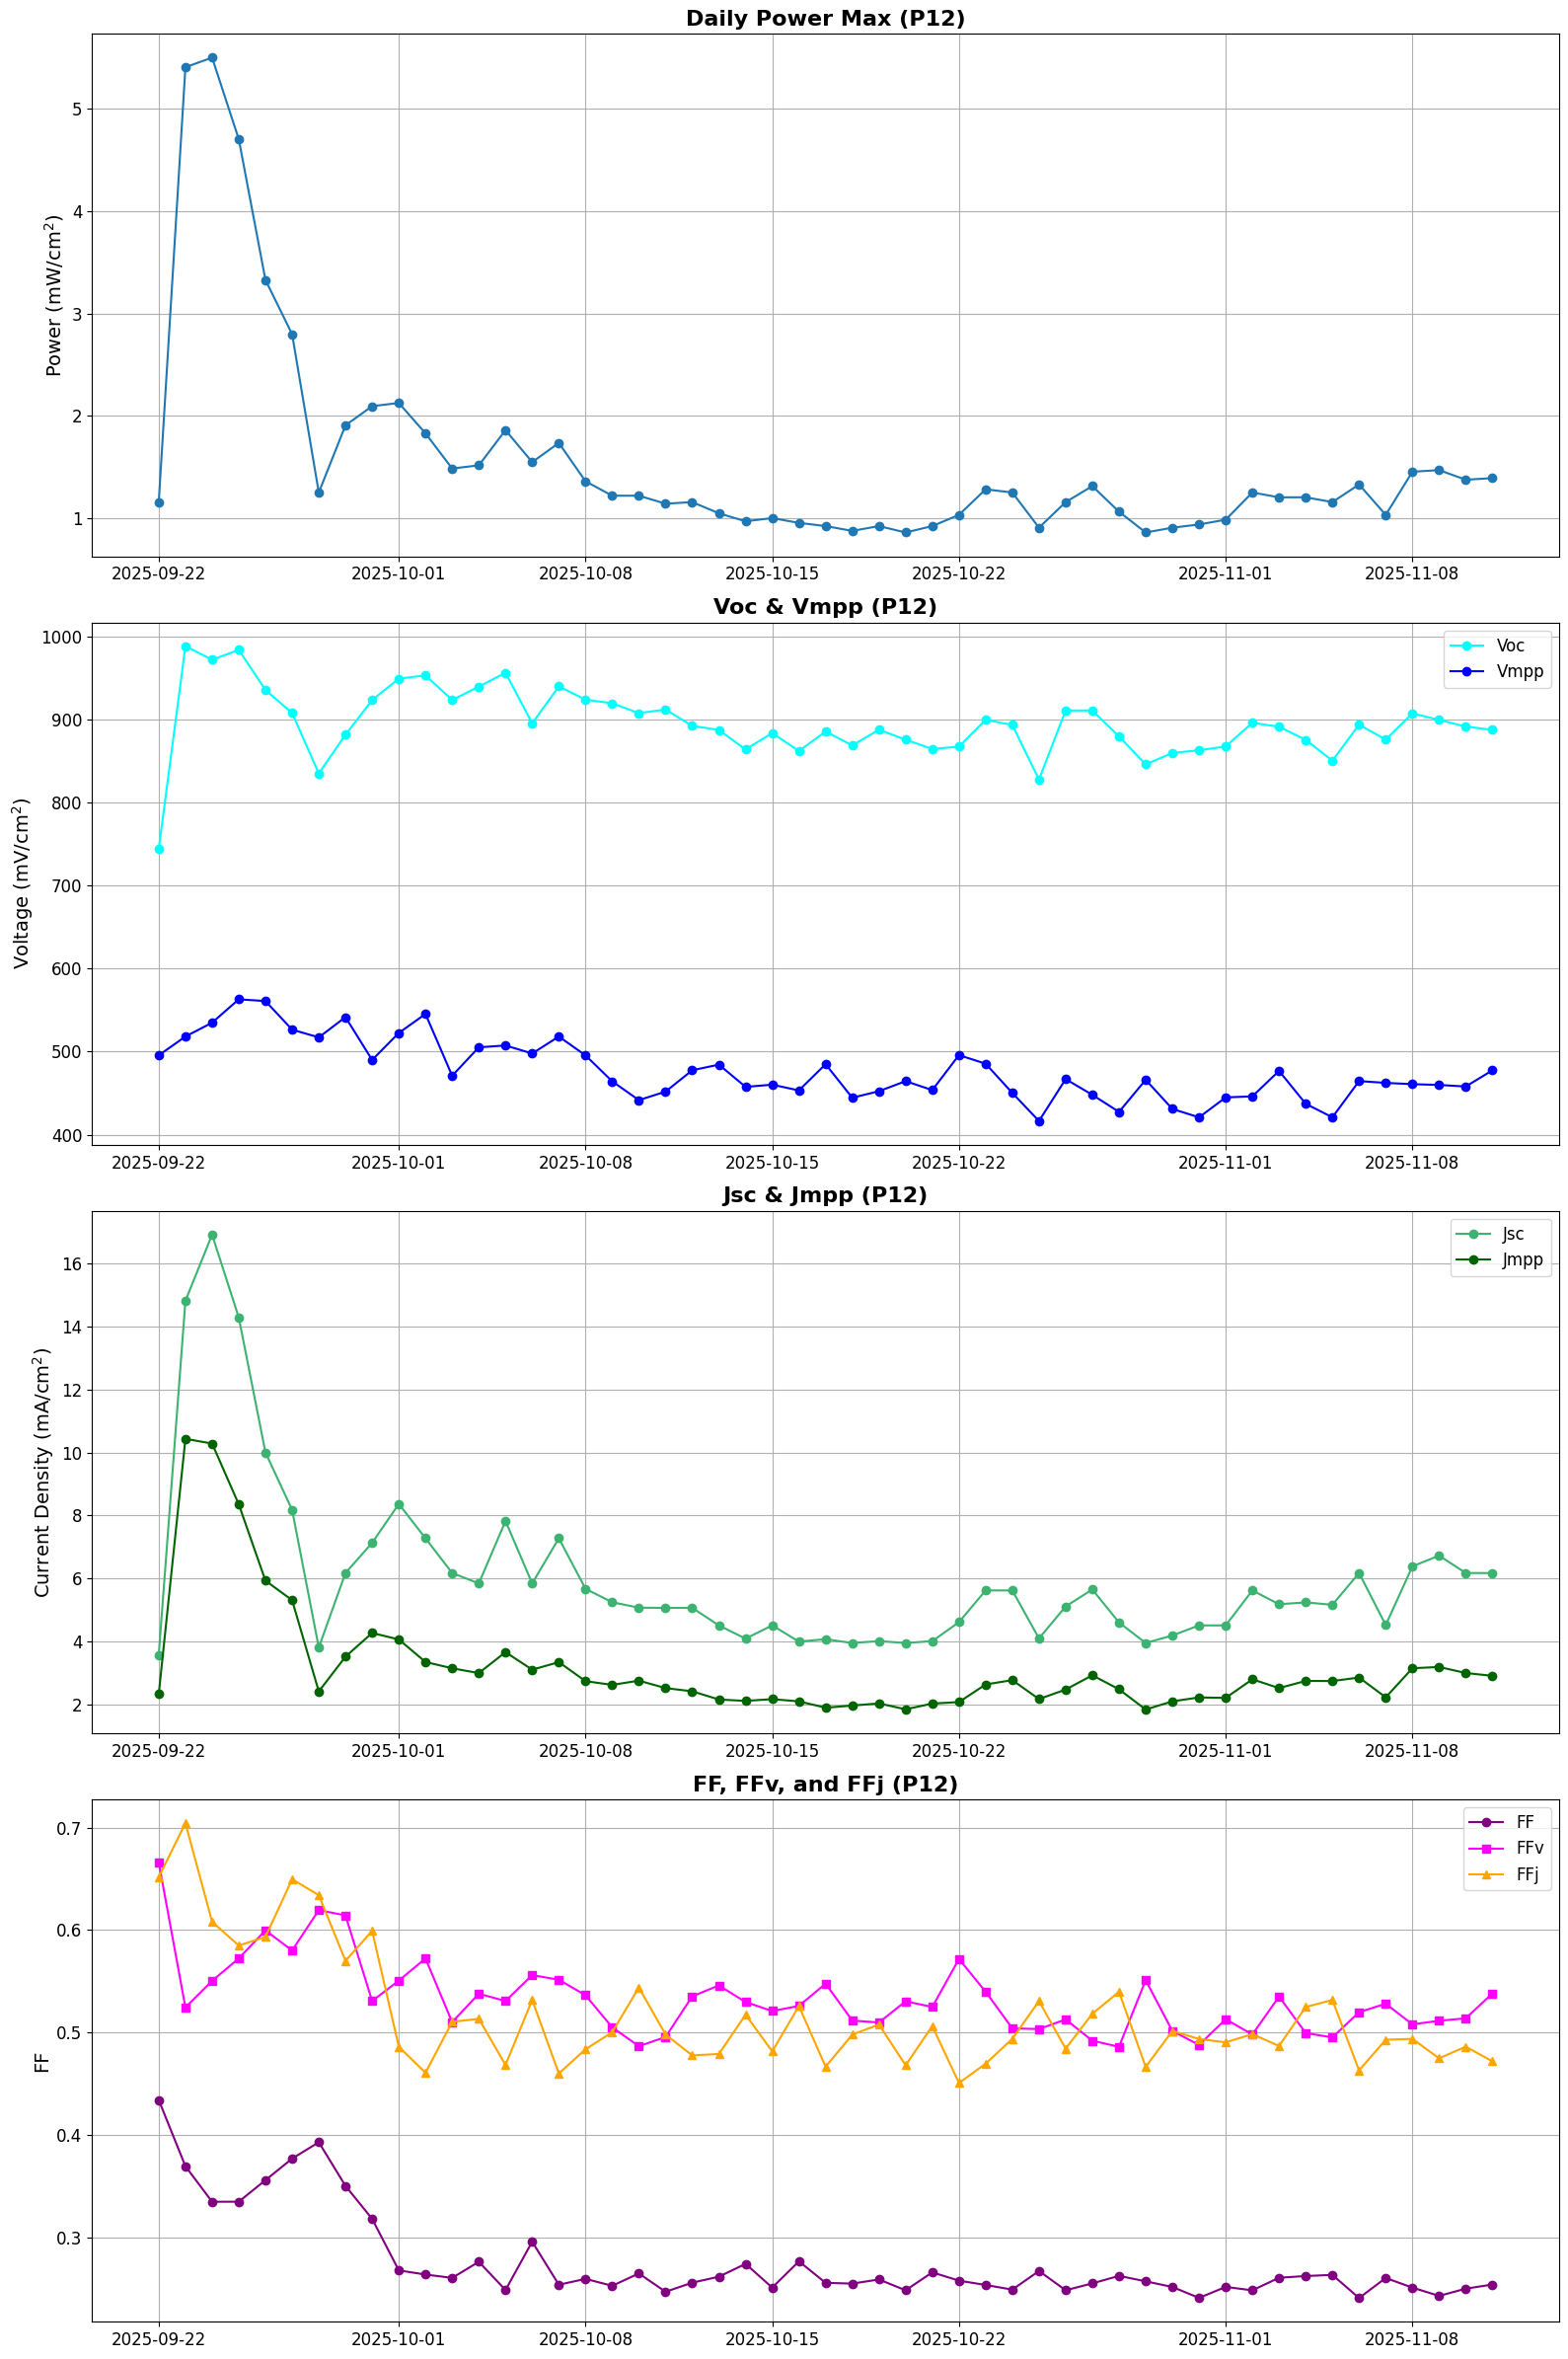

In [ ]:
df_all = plot_curves(jv, cell_id=0, filter = True, plot_pow_den_curves = False, plot_parameters = True)
print('\n')
df_all = plot_curves(jv, cell_id=1, filter = True, plot_pow_den_curves = False, plot_parameters = True)

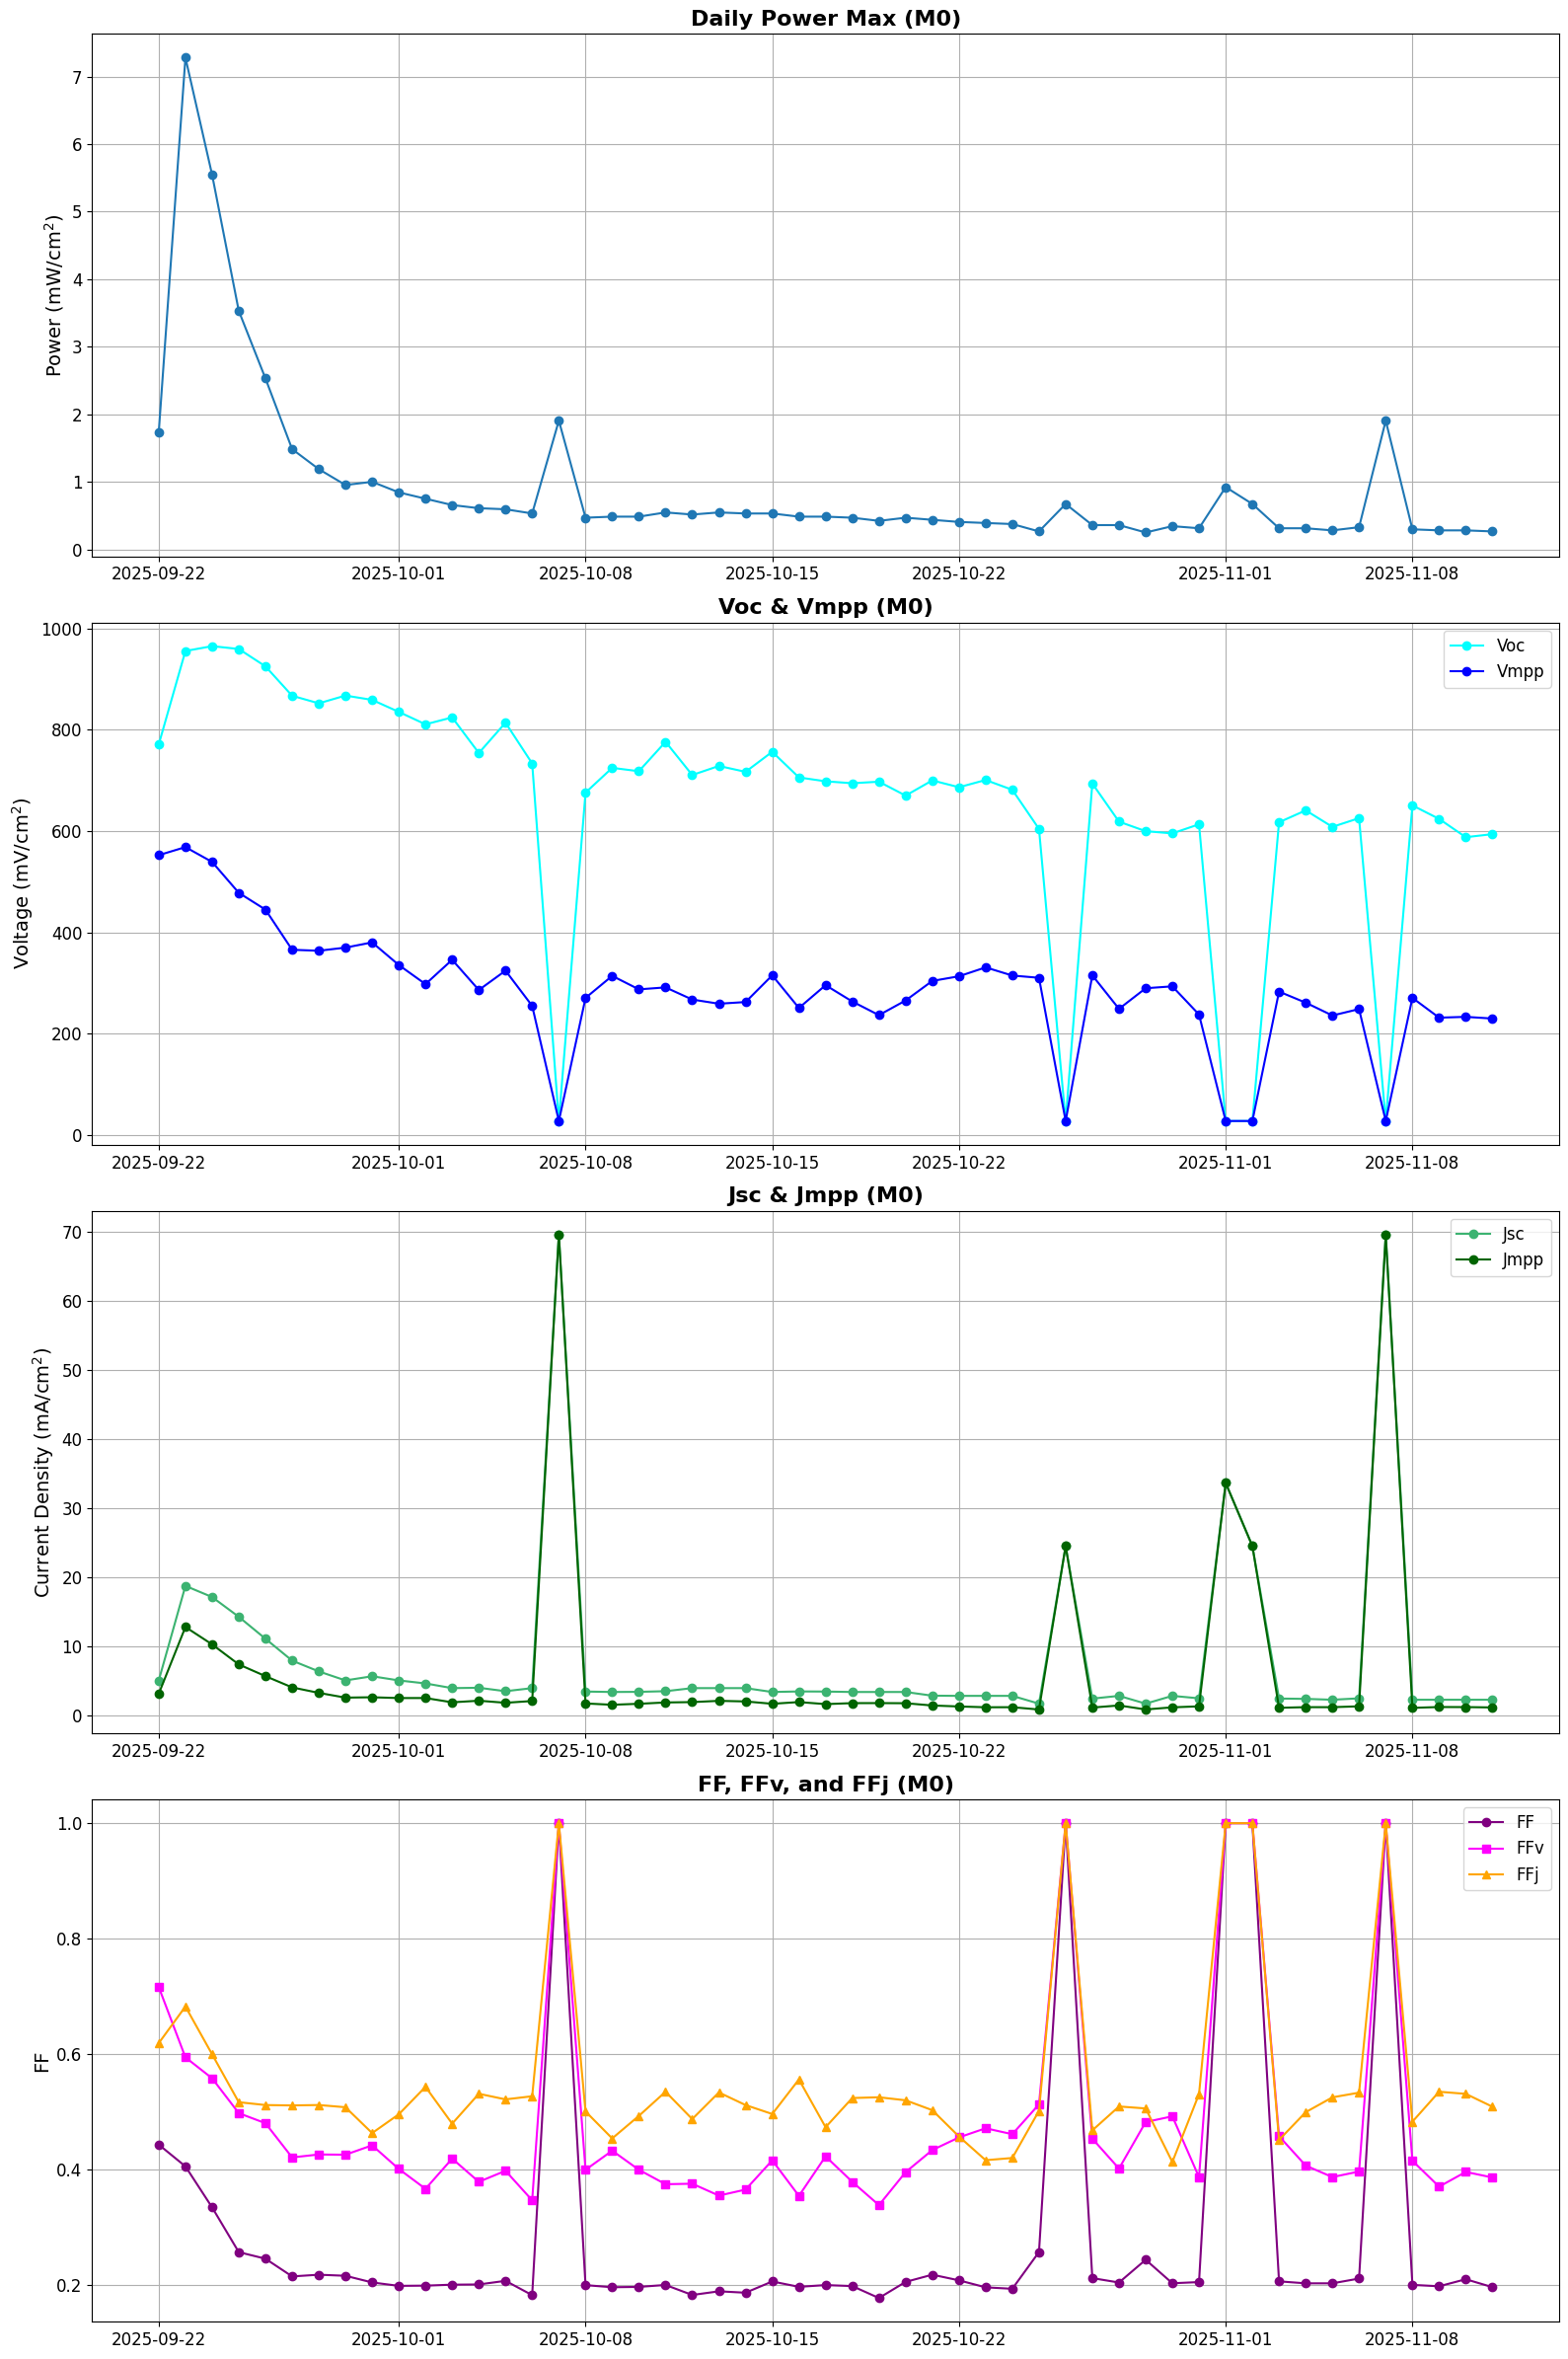

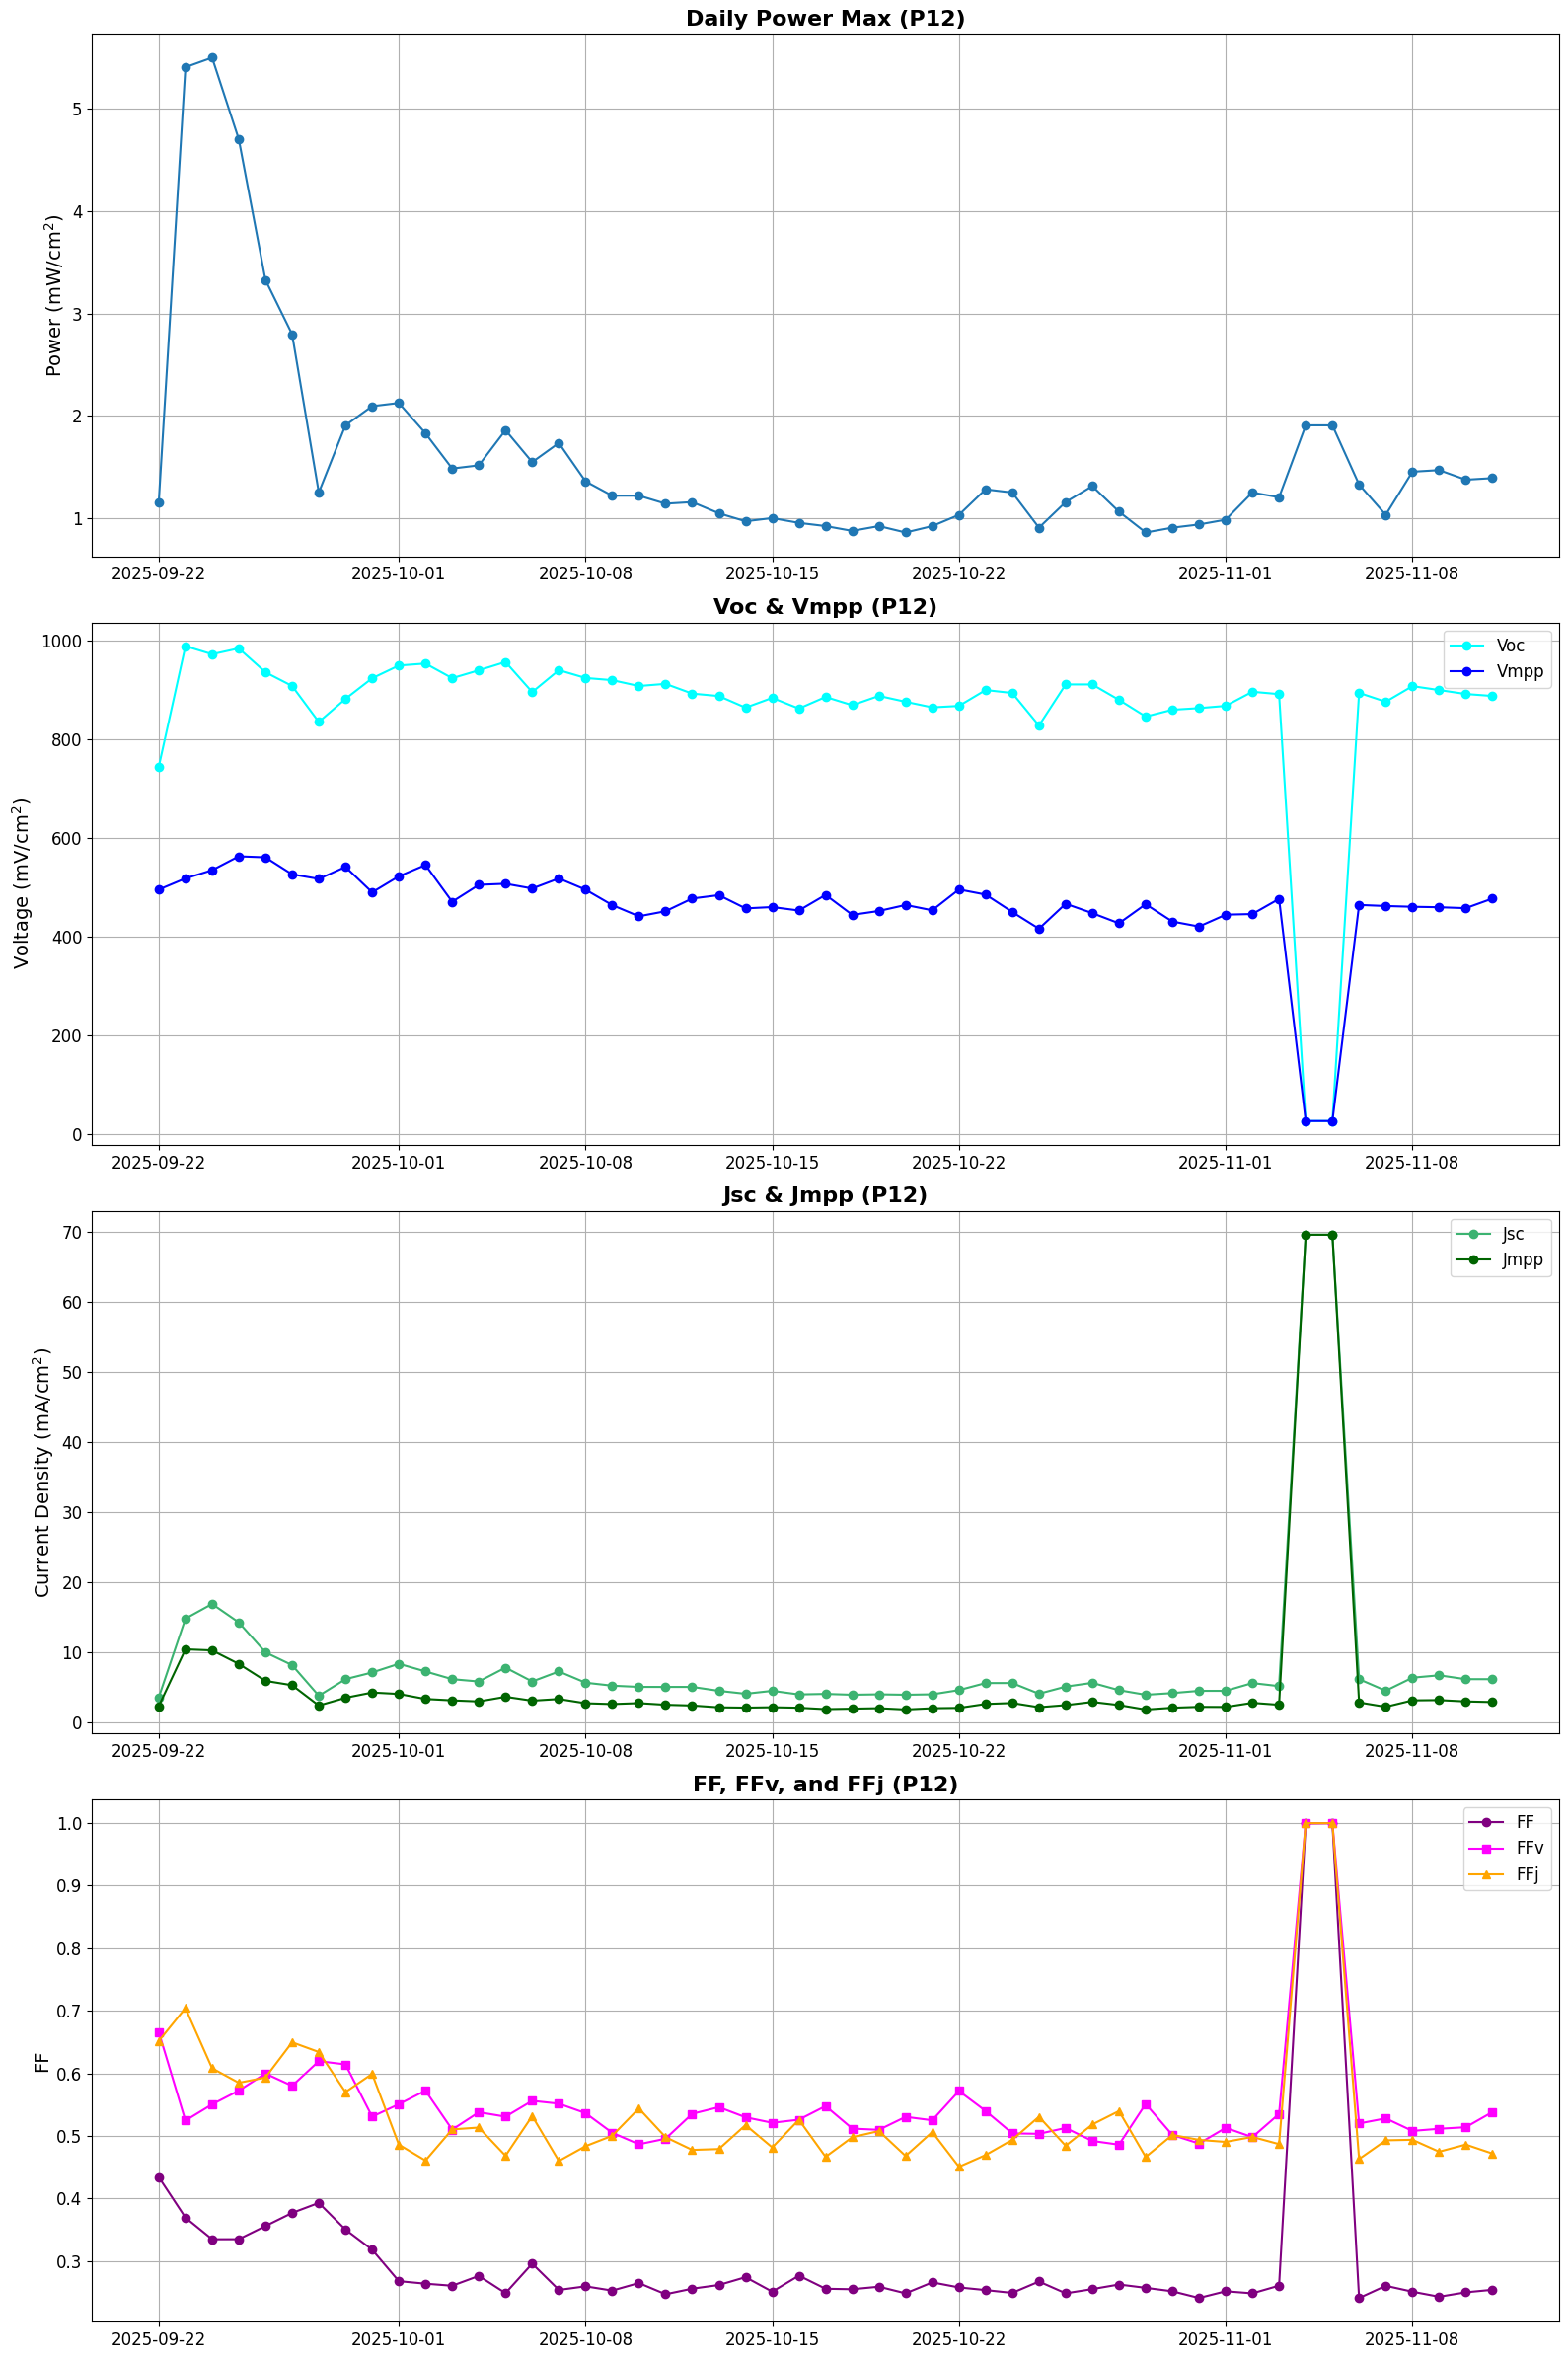

In [ ]:
df_all = plot_curves(jv, cell_id=0, filter = False, plot_pow_den_curves = False, plot_parameters = True)
print('\n')
df_all = plot_curves(jv, cell_id=1, filter = False, plot_pow_den_curves = False, plot_parameters = True)

In [ ]:
df_all

,id_curve,DPM,Vmpp,Jmpp,Voc,Jsc,FF,FFv,FFj
time,,,,,,,,,
2025-09-22,14288,1.156250,495.56,2.333219,744.07,3.580431,0.434013,0.666013,0.651659
2025-09-23,14495,5.406250,518.17,10.433352,988.19,14.813027,0.369328,0.524363,0.704336
2025-09-24,14796,5.500000,534.83,10.283642,971.81,16.912535,0.334636,0.550344,0.608049
2025-09-25,15060,4.703125,562.95,8.354428,983.66,14.284459,0.334717,0.572301,0.584861
2025-09-26,15330,3.328125,560.90,5.933544,935.40,10.001778,0.355734,0.599637,0.593249
2025-09-27,15610,2.796875,526.45,5.312708,907.66,8.178589,0.376766,0.580008,0.649587
2025-09-28,15883,1.250000,517.16,2.417047,834.86,3.811905,0.392784,0.619457,0.634078
2025-09-29,16208,1.906250,541.51,3.520249,881.53,6.175889,0.350141,0.614284,0.569999
2025-09-30,16464,2.093750,489.97,4.273221,923.26,7.132787,0.317937,0.530696,0.599096
